#INFO-6146-(01) Tensorflow and Keras
## Assignment 01: Supervised Learning Basics with Keras
**Author:** Yun-Jiung Wang

**Student Number:** 1256222

**Date:** March 1st, 2026

**Description:**

Build and train two simple neural networks using Keras:

1. A regression model

2. A classification model

**Import libs**

In [1]:
# Core
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Data Handling & Preprocessing
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation & Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,  # Regression
    accuracy_score, classification_report, confusion_matrix  # Classification
)

# Visualization
import matplotlib.pyplot as plt

**Checking Tensorflow version**

In [2]:
print(tf.__version__)

2.19.0


## **1. Regression model build, train and evaluate**
**1.1. Generate the Regression datasets**

---



In [3]:
from sklearn.datasets import make_regression

# Generate the datasets
X_reg, y_reg = make_regression(n_samples=1000, n_features=8, noise=0.2, random_state=42)

df = pd.DataFrame(X_reg, columns=[f'feature_{i}' for i in range(1, 9)])
df['target'] = y_reg
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
0,-1.407293,-0.956059,2.317637,0.125549,-1.298104,-0.724861,0.054052,0.810027,-78.200103
1,0.087016,-0.773456,1.898735,0.298798,-1.036144,-2.085792,0.973726,-0.343206,55.719576
2,1.322744,-1.496159,-0.918212,0.456688,-0.169123,0.910418,1.573734,-0.605156,134.435548
3,-3.007632,1.097300,-1.565648,-0.495878,0.571179,-2.426392,-2.386930,1.284096,-609.736372
4,-0.387131,-0.549557,0.859588,-0.766657,-0.045411,1.719378,1.992515,-0.605861,232.329603


**Check the dataset**

In [4]:
print(f"X shape: {X_reg.shape}")  # (1000, 8)
print(f"y shape: {y_reg.shape}")  # (1000,)
print(f"y range: {y_reg.min():.2f} ~ {y_reg.max():.2f}")

X shape: (1000, 8)
y shape: (1000,)
y range: -609.74 ~ 565.58


**1.2. Split Train and Test Dataset**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg,
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42     # for reproducibility
)

print(X_train.shape)  # 80% of data
print(X_test.shape)   # 20% of data

(800, 8)
(200, 8)


**1.3. Scaler the dataset**

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(800, 8)
(200, 8)


**1.4. Define the Model**

**Dense:**

The "Dense" Architecture (128 → 64 → 32 → 1)
This decreasing number of neurons represents a Feature Hierarchy.

**Optimizer: Adam**

Instead of using a single learning rate for every parameter, Adam adjusts the learning rate for each weight individually and Adam speeds up on long, flat slopes and slows down when the terrain gets tricky (noisy data).

**Loss: MSE**

To minimize the distance between prediction and reality. MSE is a classic choice for regression model.

**Metrics: MAE & RMSE**

To see the average amount of the model is "off" by.

In [19]:
model = tf.keras.Sequential([
    # Input layer
    tf.keras.layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    # Output layer (single value)
    tf.keras.layers.Dense(1)  # No activation = linear output for regression
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error","root_mean_squared_error"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

**1.5. Train Model**

In [8]:
# With the 1000 dataset, batch size =32 and epoch =50 is enough, and able to prove by the step 1.6
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

print("Training complete.")

Training complete.


**1.6. Monitor Loss Curve**

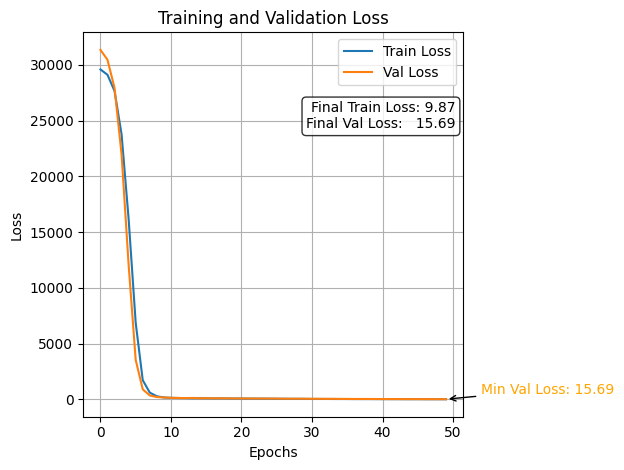

In [9]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Get final values
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
min_val_loss = min(history.history['val_loss'])
min_epoch = history.history['val_loss'].index(min_val_loss)

# label the min
plt.annotate(f'Min Val Loss: {min_val_loss:.2f}',
             xy=(min_epoch, min_val_loss),
             xytext=(min_epoch + 5, min_val_loss + 500),
             arrowprops=dict(arrowstyle='->'),
             color='orange')

# show final numbers on the graph
plt.text(0.98, 0.75,
         f'Final Train Loss: {final_train_loss:.2f}\nFinal Val Loss:   {final_val_loss:.2f}',
         transform=plt.gca().transAxes,
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**1.6.1. Observation of the Loss Curve:**

The loss converged at around epoch 7-8, dropping from ~30,000 to 18.07 (99.9% reduction), indicating that epochs=50 is more than sufficient.
The close alignment between Train Loss (10.87) and Val Loss (18.07) suggests no significant overfitting and the model generalizes well.

**1.7. Rgression Test Result & Evaluate the Model**

In [10]:
# Test result
reg_result = model.evaluate(X_test, y_test, verbose=0)

# get loss, mae
loss = reg_result[0]
mae  = reg_result[1]

# print loss, mae
print("Test Result:")
print(f"Loss: {loss:.2f}")
print(f"MAE:  {mae:.2f}")

# Predict
y_pred = model.predict(X_test)

#Metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\nEvaluation Metrics:")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² :{r2:.4f}")

Test Result:
Loss: 16.50
MAE:  3.16
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Evaluation Metrics:
MSE:  16.50
RMSE: 4.06
R² :0.9994


**1.8. Conclusion of the Regression:**

The evaluation metrics indicates strong model performance.The R² score of 0.9995 shows the model explains 99.95% of
the variance in the target variable, while the low RMSE (3.85)
and MAE (3.06) confirm minimal prediction error.

## **2. Classification model build, train and evaluate**

**2.1. Import the libs and generate the dataset:**

In [11]:
from sklearn.datasets import make_classification

X_clf, y_clf = make_classification(
    n_samples=1000,       # 1000 dataset
    n_features=8,         # 8 features
    n_classes=2,          # 2 classes (binary)
    n_informative=4,      # 4 meaningful feature
    n_redundant=2,        # 2 redundant features
    random_state=42
)

# Preview the dataset
df_clf = pd.DataFrame(X_clf, columns=[f'feature_{i}' for i in range(1, 9)])
df_clf['target'] = y_clf
df_clf.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
0,-1.714454,-0.101923,0.386791,1.465905,-0.103786,0.156844,-1.056426,-1.048378,1
1,1.054036,0.351385,2.182377,1.979615,-0.315177,0.700564,-0.868436,-0.388255,1
2,0.022196,0.610570,-0.200683,-1.093425,0.455908,2.777299,0.894582,-0.023287,1
3,0.739463,1.081121,0.843632,-0.444215,0.634621,0.864181,0.887543,-0.556825,1
4,0.026572,0.938846,1.184835,-0.439576,-0.527158,-0.266993,-0.045593,1.417888,1


**2.2. Class Distribution:**

In [12]:
unique, counts = np.unique(y_clf, return_counts=True)
print("Class Distribution:")
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} samples")

Class Distribution:
  Class 0: 498 samples
  Class 1: 502 samples


**2.3. Data Preprocessing: (Split train, test dataset and Scaler the dataset)**

In [13]:
# Split data
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42
)

# Scale
scaler_clf = StandardScaler() # for classification
X_train_clf = scaler_clf.fit_transform(X_train_clf)
X_test_clf  = scaler_clf.transform(X_test_clf)

print(X_train_clf.shape)
print(X_test_clf.shape)

(800, 8)
(200, 8)


**2.4. Build the model**

Add the Dropout parameter to shut down neurons to prevent dependence on specific paths. And use regularizer.l2 to solve the overfitting problem.

For the Dense, since the dataset has only 8 features, and 2 classes (biniary), the dense starts at 64 would be enough.

In [14]:
from tensorflow.keras import regularizers # solve the overfitting issue

def classification_model(input_shape):
    model = tf.keras.Sequential([

    # Enables fast learning and non-linearity
      tf.keras.layers.Dense(64, activation="relu",

      # Prevents weights from getting too large
      kernel_regularizer=regularizers.l2(0.01),
      input_shape=(input_shape,)),

      # Randomly shuts off neurons to force redundancy.
      tf.keras.layers.Dropout(0.5),
      tf.keras.layers.Dense(32, activation="relu",

    #After compare the result of using 0.1 and 0.5, we found that the value 0.5 is better
      kernel_regularizer=regularizers.l2(0.01)),
      tf.keras.layers.Dropout(0.5),
      tf.keras.layers.Dense(1, activation="sigmoid") # Converts output to a 0–1 probability
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy", # Since this is a binary dataset, the "binary corssentropy loss is a suitable choice"
        metrics=["accuracy"] # Using Accuarcy for classification dataset to evaluate the result
    )
    return model

# execute
model_clf = classification_model(X_train_clf.shape[1])
model_clf.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

**2.4. Train the model**

In [15]:
clf_history = model_clf.fit(
    X_train_clf, y_train_clf,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

print("Training complete.")

Training complete.


**2.5. Observe the Loss & Accuracy:**

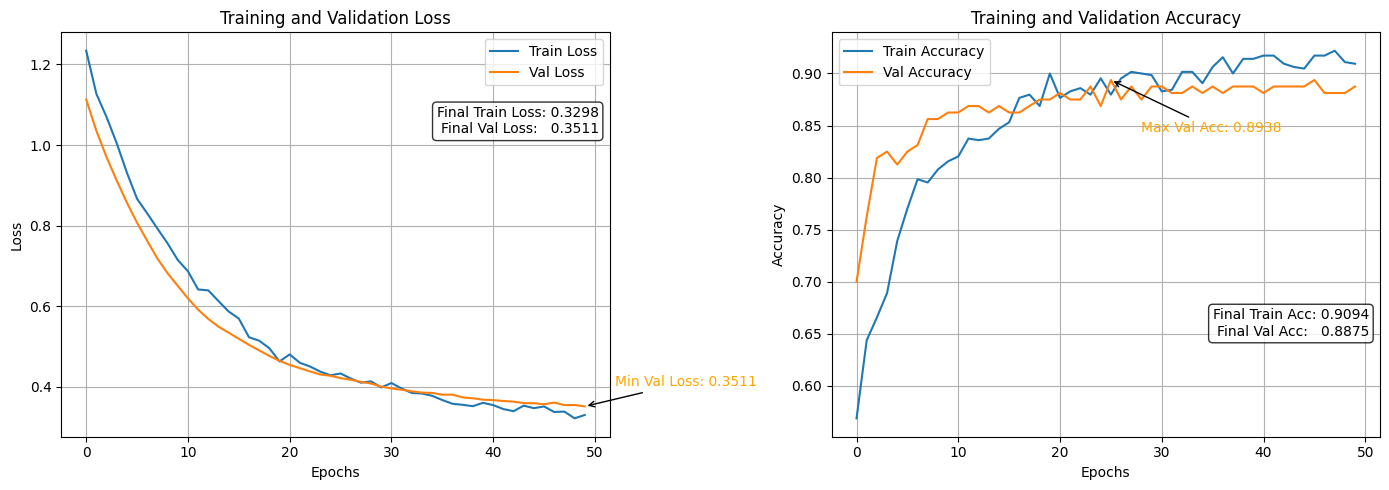

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Left graph：Loss
ax1 = axes[0]
ax1.plot(clf_history.history['loss'], label='Train Loss')
ax1.plot(clf_history.history['val_loss'], label='Val Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# get values
final_train_loss = clf_history.history['loss'][-1]
final_val_loss   = clf_history.history['val_loss'][-1]
min_val_loss     = min(clf_history.history['val_loss'])
min_val_epoch    = clf_history.history['val_loss'].index(min_val_loss)

# Label lowest Val Loss
ax1.annotate(f'Min Val Loss: {min_val_loss:.4f}',
             xy=(min_val_epoch, min_val_loss),
             xytext=(min_val_epoch + 3, min_val_loss + 0.05),
             arrowprops=dict(arrowstyle='->'),
             color='orange')

# Explain
ax1.text(0.98, 0.75,
         f'Final Train Loss: {final_train_loss:.4f}\nFinal Val Loss:   {final_val_loss:.4f}',
         transform=ax1.transAxes,
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Right Graph：Accuracy
ax2 = axes[1]
ax2.plot(clf_history.history['accuracy'], label='Train Accuracy')
ax2.plot(clf_history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

# get values
final_train_acc = clf_history.history['accuracy'][-1]
final_val_acc   = clf_history.history['val_accuracy'][-1]
max_val_acc     = max(clf_history.history['val_accuracy'])
max_val_epoch   = clf_history.history['val_accuracy'].index(max_val_acc)

# label highest Val Accuracy
ax2.annotate(f'Max Val Acc: {max_val_acc:.4f}',
             xy=(max_val_epoch, max_val_acc),
             xytext=(max_val_epoch + 3, max_val_acc - 0.05),
             arrowprops=dict(arrowstyle='->'),
             color='orange')

# Explain
ax2.text(0.98, 0.25,
         f'Final Train Acc: {final_train_acc:.4f}\nFinal Val Acc:   {final_val_acc:.4f}',
         transform=ax2.transAxes,
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

**2.5.1 Observation of the Loss and Accuracy Graph:**

The model shows significant improvement after applying Dropout
and L2 Regularization. The close alignment between Train Loss
(0.3210) and Val Loss (0.3521) indicates minimal overfitting.
The model achieved a validation accuracy of 88.13%, suggesting
it generalizes well to unseen data.

**2.6. Evaluate and Predict:**

In [17]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)
import seaborn as sns

# Predict
y_pred_clf_prob = (model_clf.predict(X_test_clf))
y_pred_clf = (y_pred_clf_prob > 0.5).astype(int)

#f1 score
f1 = f1_score(y_test_clf, y_pred_clf)
# recall
rec = classification_report(y_test_clf, y_pred_clf, target_names=['Class 0', 'Class 1'])

# Show Results
print(f"\nF1 Score: {f1:.4f}")
print(f"\nEvaluation Report:\n{rec}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

F1 Score: 0.9254

Evaluation Report:
              precision    recall  f1-score   support

     Class 0       0.93      0.92      0.92       100
     Class 1       0.92      0.93      0.93       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.92       200
weighted avg       0.93      0.93      0.92       200



**2.6.1. Observation:**

With the Accuracy 92% and F1 score 0.92, shows that the binary classification model distingushes the classes well and demonstrates strong classification performance on unseen data.

**2.7. Visualization:**

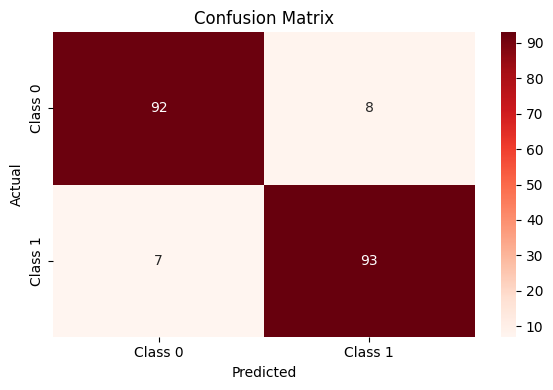

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

**2.8. Conclusion of the Classification Model:**

The binary classification model achieved strong performance on the synthetic
dataset, with both Accuracy and F1 Score reaching 92%. The Confusion Matrix
confirms minimal misclassification across both Class 0 and Class 1, indicating
the model generalizes well to unseen data. The application of Dropout and L2
Regularization proved effective in reducing overfitting compared to the initial
model.